In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Dataset = https://www.kaggle.com/datasets/vivek468/superstore-dataset-final

**PROBLEM STATEMENT**


A national retail chain wants to analyze its 4-year sales history to understand which products, regions, and
customer segments drive revenue and profit. The goal is to produce an executive-level analysis with
actionable recommendations.

1. LOAD DATA

In [ ]:
df = pd.read_csv("/content/Sample - Superstore.csv", encoding='latin1')
print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())
print(df.duplicated().sum())

(9994, 21)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
0


 2. DATA PREPARATION

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])#Fix Dtype
df['Ship Date'] = pd.to_datetime(df['Ship Date'])#Fix Dtype
df['Year'] = df['Order Date'].dt.year# extracting year from order date
df['Month'] = df['Order Date'].dt.month# extracting month from order date
df['Quarter'] = df['Order Date'].dt.quarter# extracting Quarters from order date
df['Profit Margin'] = df['Profit'] / df['Sales'] # Profit as fraction of sales

3. BUSINESS KPI SUMMARY

In [ ]:
print("\n=== OVERALL KPIs ===")
print(f"Total Sales: ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Avg Discount: {df['Discount'].mean():.2%}")
print(f"Profit Margin: {df['Profit'].sum()/df['Sales'].sum():.2%}")


=== OVERALL KPIs ===
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Avg Discount: 15.62%
Profit Margin: 12.47%


4. SQL-STYLE ANALYSIS

In [ ]:
# KPIs by Region (like SQL: SELECT Region, SUM(Sales), SUM(Profit) GROUP BY Region)
region_kpi = df.groupby('Region').agg(
Total_Sales=('Sales', 'sum'),
Total_Profit=('Profit', 'sum'),
Avg_Discount=('Discount', 'mean'),
Orders=('Order ID', 'nunique')
).sort_values('Total_Sales', ascending=False).round(2)
print("\n=== KPIs by Region ===")
print(region_kpi)
# Sub-category profitability
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
print("\n=== Profit by Sub-Category ===")
print(subcat_profit)
# Segment analysis
segment = df.groupby('Segment')[['Sales', 'Profit']].sum()
print("\n=== Sales & Profit by Segment ===")
print(segment)



=== KPIs by Region ===
         Total_Sales  Total_Profit  Avg_Discount  Orders
Region                                                  
West       725457.82     108418.45          0.11    1611
East       678781.24      91522.78          0.15    1401
Central    501239.89      39706.36          0.24    1175
South      391721.90      46749.43          0.15     822

=== Profit by Sub-Category ===
Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64

=== Sales & Profit by Segment ===
                    Sales       Profit
Segment                               
Consu

5. SEASONAL ANALYSIS

In [ ]:
monthly = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

6. VISUALIZATIONS

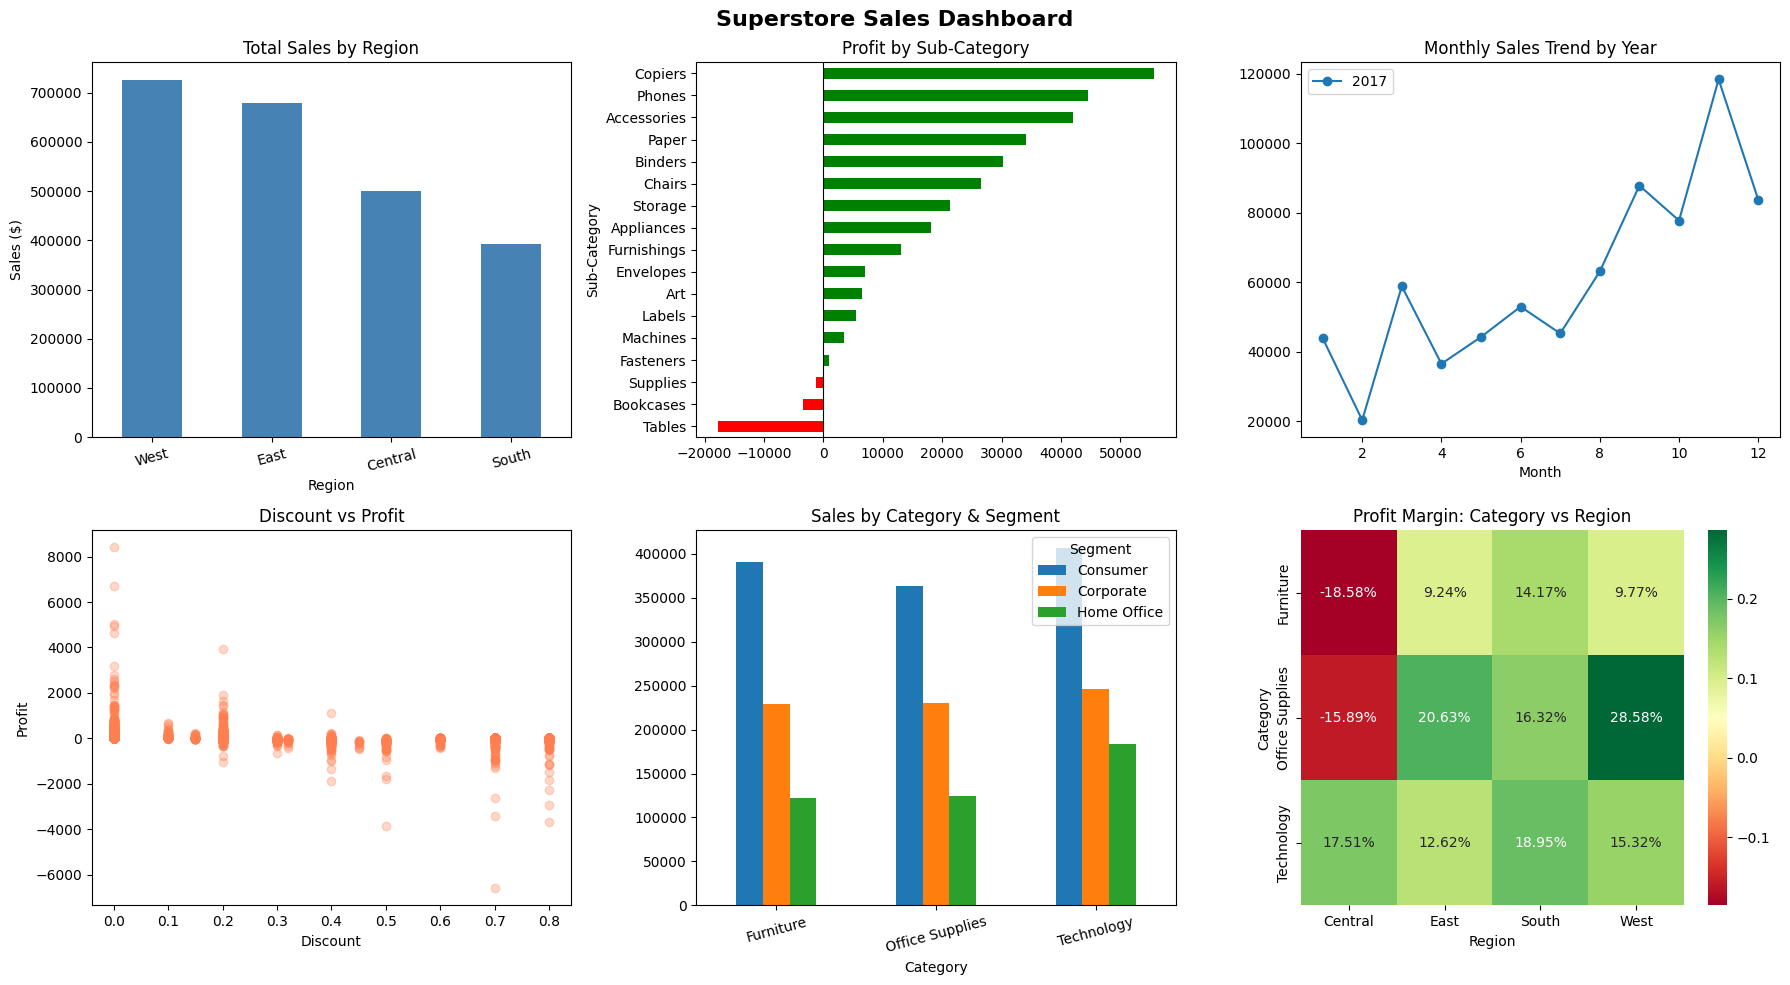

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
# a. Sales by Region
region_kpi['Total_Sales'].plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title("Total Sales by Region")
axes[0,0].set_ylabel("Sales ($)")
axes[0,0].tick_params(axis='x', rotation=15)
# b. Profit by Sub-Category
colors = ['red' if x < 0 else 'green' for x in subcat_profit]
subcat_profit.plot(kind='barh', ax=axes[0,1], color=colors)
axes[0,1].set_title("Profit by Sub-Category")
axes[0,1].axvline(0, color='black', linewidth=0.8)
# c. Monthly Sales Trend
for yr in df['Year'].unique():
 subset = monthly[monthly['Year'] == yr]
axes[0,2].plot(subset['Month'], subset['Sales'], marker='o', label=str(yr))
axes[0,2].set_title("Monthly Sales Trend by Year")
axes[0,2].legend()
axes[0,2].set_xlabel("Month")
# d. Discount vs Profit scatter
axes[1,0].scatter(df['Discount'], df['Profit'], alpha=0.3, color='coral')
axes[1,0].set_title("Discount vs Profit")
axes[1,0].set_xlabel("Discount")
axes[1,0].set_ylabel("Profit")
# e. Sales by Category and Segment
pivot = df.pivot_table(values='Sales', index='Category', columns='Segment', aggfunc='sum')
pivot.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title("Sales by Category & Segment")
axes[1,1].tick_params(axis='x', rotation=15)
# f. Profit Margin Heatmap
heatmap_data = df.pivot_table(values='Profit Margin', index='Category', columns='Region', aggfunc='mean')
sns.heatmap(heatmap_data, annot=True, fmt=".2%", cmap='RdYlGn', ax=axes[1,2])
axes[1,2].set_title("Profit Margin: Category vs Region")
plt.suptitle("Superstore Sales Dashboard", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("retail_dashboard.png", dpi=150)
plt.show()

7. EXPORT TO EXCEL

In [ ]:
with pd.ExcelWriter("superstore_report.xlsx", engine='openpyxl') as writer:
 region_kpi.to_excel(writer, sheet_name='Region KPIs')
subcat_profit.to_frame('Profit').to_excel(writer, sheet_name='Sub-Category Profit')
segment.to_excel(writer, sheet_name='Segment Analysis')
monthly.to_excel(writer, sheet_name='Monthly Trend', index=False)
print("Excel report saved!")

Excel report saved!


**📊 Key Insights**

High Discounts Reduce Profit
There is a strong negative relationship between discount and profit. As discounts increase, profit margins decrease significantly. This indicates that excessive discounting is harming overall profitability.

Unprofitable Product Categories Exist
Certain sub-categories such as Tables and Bookcases are generating negative profit. This means the company is selling these products at a loss despite generating revenue.

Sales and Profit Are Not the Same
Regions with high sales (e.g., West) do not necessarily have the highest profit margins. This shows that focusing only on revenue can be misleading for business decisions.

Seasonal Sales Pattern Identified
Sales consistently peak in Q4 (October–December), indicating strong seasonality driven by holiday demand.

Customer Segments Behave Differently
The Consumer segment contributes the highest sales volume, while the Corporate segment generates higher average order value, indicating different revenue strategies are needed.


**🧠 Business Recommendations**

Limit discount levels to protect profit margins
Review or discontinue loss-making products (Tables, Bookcases)
Focus on profit optimization instead of just increasing sales
Increase inventory and marketing efforts before Q4 peak season
Use targeted strategies: volume-focused for Consumers and value-focused for Corporate clients


**📌 Final Conclusion**

This analysis reveals that the business is prioritizing sales growth over profitability, which is leading to losses in certain areas. By optimizing discount strategies, removing unprofitable products, and leveraging seasonal demand, the company can significantly improve its overall financial performance.